# 🔗 Hands-On Bab 3 — Representasi Jaringan
### Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi

Notebook ini membangun **studi kasus jaringan startup** dari buku dan merepresentasikannya dalam tiga bentuk: **adjacency matrix, edge list,** dan **adjacency list** — lengkap dengan seluruh **Latihan Soal Bab 3**.

In [1]:
!pip install -q networkx matplotlib numpy pandas
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Studi Kasus: Jaringan Startup

Lima orang di sebuah startup: **Anya** (manajer pemasaran), **Budi** (desainer grafis), **Cici** (copywriter), **Didi** (programmer), **Eka** (teman Budi di luar kantor).

Relasi:
- A–B: kolaborasi materi promosi (profesional)
- A–C: konsultasi konten (profesional)
- A–D: bantuan teknis sesekali (profesional-occasional)
- B–C: proyek kreatif (profesional)
- B–E: pertemanan (personal)
- C–D: saudara sepupu (personal)

n = 5 simpul, m = 6 sisi


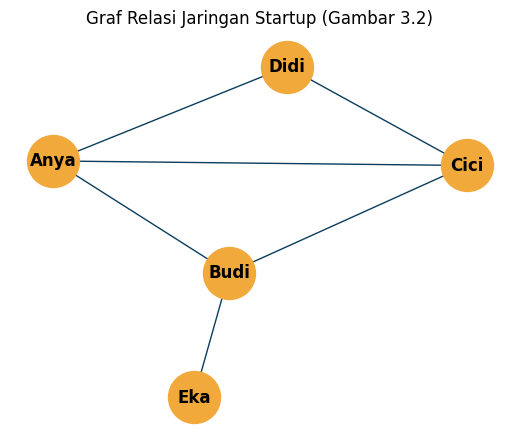

In [2]:
G = nx.Graph()
G.add_nodes_from([
    ("Anya", {"peran": "Manajer Pemasaran"}),
    ("Budi", {"peran": "Desainer Grafis"}),
    ("Cici", {"peran": "Copywriter"}),
    ("Didi", {"peran": "Programmer"}),
    ("Eka",  {"peran": "Teman Budi"}),
])
G.add_edges_from([
    ("Anya","Budi", {"jenis": "profesional"}),
    ("Anya","Cici", {"jenis": "profesional"}),
    ("Anya","Didi", {"jenis": "profesional-occasional"}),
    ("Budi","Cici", {"jenis": "profesional"}),
    ("Budi","Eka",  {"jenis": "personal"}),
    ("Cici","Didi", {"jenis": "personal"}),
])

print(f"n = {G.number_of_nodes()} simpul, m = {G.number_of_edges()} sisi")

plt.figure(figsize=(5, 4))
pos = nx.spring_layout(G, seed=2)
nx.draw(G, pos, with_labels=True, node_color="#F2A93B", node_size=1400,
        font_weight="bold", edge_color="#0B3D5C")
plt.title("Graf Relasi Jaringan Startup (Gambar 3.2)")
plt.show()

## 3.1 Adjacency Matrix

Matriks n×n dengan A[i,j] = 1 jika simpul i dan j terhubung.

In [3]:
order = ["Anya", "Budi", "Cici", "Didi", "Eka"]
A = nx.to_numpy_array(G, nodelist=order, dtype=int)
df_adj = pd.DataFrame(A, index=order, columns=order)
print("Adjacency Matrix:")
df_adj

Adjacency Matrix:


,Anya,Budi,Cici,Didi,Eka
Anya,0,1,1,1,0
Budi,1,0,1,0,1
Cici,1,1,0,1,0
Didi,1,0,1,0,0
Eka,0,1,0,0,0


## 3.2 Edge List

Daftar pasangan simpul yang terhubung — format ringkas untuk pertukaran data.

In [4]:
edge_list = list(G.edges(data=True))
for u, v, attr in edge_list:
    print(f"({u}, {v})  jenis: {attr['jenis']}")

(Anya, Budi)  jenis: profesional
(Anya, Cici)  jenis: profesional
(Anya, Didi)  jenis: profesional-occasional
(Budi, Cici)  jenis: profesional
(Budi, Eka)  jenis: personal
(Cici, Didi)  jenis: personal


## 3.3 Adjacency List

Daftar tetangga untuk tiap simpul — representasi paling efisien untuk jaringan besar dan jarang.

In [5]:
for node in G.nodes():
    tetangga = list(G.neighbors(node))
    print(f"{node}: {tetangga}")

Anya: ['Budi', 'Cici', 'Didi']
Budi: ['Anya', 'Cici', 'Eka']
Cici: ['Anya', 'Budi', 'Didi']
Didi: ['Anya', 'Cici']
Eka: ['Budi']


## ✅ Latihan Soal Bab 3

**1.** Jelaskan perbedaan mendasar antara adjacency matrix dan adjacency list. Mengapa adjacency list lebih banyak digunakan dalam implementasi algoritma AJS untuk jaringan besar? Dukung argumen Anda dengan analisis kompleksitas memori dan waktu.

**2.** Berdasarkan jaringan startup (n=5, m=6): (a) buktikan adjacency matrix simetris, (b) hitung degree tiap simpul dari baris matriks, (c) buktikan total nilai 1 dalam adjacency matrix = 2m = 12.

**3.** Startup berkembang menjadi 500 karyawan dengan rata-rata 15 relasi per orang. Hitung: total sisi, kebutuhan memori adjacency matrix (1 byte/elemen), representasi mana yang lebih efisien?

**4.** Menggunakan Python (NetworkX): buat jaringan startup dengan semua atribut simpul dan sisi, cetak adjacency matrix berbobot, tampilkan tetangga Cici beserta bobot relasinya.

### ✏️ Jawaban Soal 1 (tulis di sini)

_1._

### 🧮 Soal 2 — Verifikasi dengan kode

In [ ]:
# (a) Buktikan adjacency matrix simetris
is_symmetric = np.array_equal(A, A.T)
print("Adjacency matrix simetris?", is_symmetric)

# (b) Degree tiap simpul dari penjumlahan baris matriks
degree_dari_matriks = A.sum(axis=1)
for name, deg in zip(order, degree_dari_matriks):
    print(f"  deg({name}) = {deg}")

# (c) Buktikan total nilai 1 dalam matriks = 2m
total_satu = A.sum()
m = G.number_of_edges()
print(f"\nTotal nilai 1 dalam matriks = {total_satu}, 2m = {2*m}  -> {'COCOK' if total_satu == 2*m else 'TIDAK COCOK'}")

### 🧮 Soal 3 — Hitung dengan kode

In [ ]:
n_karyawan = 500
rata2_relasi = 15

total_sisi = (n_karyawan * rata2_relasi) // 2
memori_adjmatrix_bytes = n_karyawan ** 2  # 1 byte per elemen
memori_adjlist_bytes = total_sisi * 2 * 8  # perkiraan: tiap sisi disimpan 2x (u->v dan v->u), tiap referensi ~8 byte

print(f"Total sisi (m)                    : {total_sisi:,}")
print(f"Memori adjacency matrix (1B/elemen): {memori_adjmatrix_bytes:,} byte (~{memori_adjmatrix_bytes/1024:.1f} KB)")
print(f"Perkiraan memori adjacency list     : {memori_adjlist_bytes:,} byte (~{memori_adjlist_bytes/1024:.1f} KB)")
print()
print("Kesimpulan: pada jaringan besar & jarang (density rendah),")
print("adjacency list jauh lebih hemat memori dibanding adjacency matrix.")
print(f"Density jaringan ini = {2*total_sisi / (n_karyawan*(n_karyawan-1)):.4f}  (sangat jarang)")

### 🧮 Soal 4 — Jaringan berbobot dengan NetworkX

In [ ]:
G_bobot = nx.Graph()
G_bobot.add_nodes_from([
    ("Anya", {"peran": "Manajer Pemasaran"}),
    ("Budi", {"peran": "Desainer Grafis"}),
    ("Cici", {"peran": "Copywriter"}),
    ("Didi", {"peran": "Programmer"}),
    ("Eka",  {"peran": "Teman Budi"}),
])
# bobot = intensitas relasi (skala 1-5, contoh nilai)
G_bobot.add_weighted_edges_from([
    ("Anya","Budi", 4), ("Anya","Cici", 3), ("Anya","Didi", 1),
    ("Budi","Cici", 4), ("Budi","Eka", 5), ("Cici","Didi", 3),
])

# cetak adjacency matrix berbobot
A_bobot = nx.to_numpy_array(G_bobot, nodelist=order, weight="weight")
print("Adjacency Matrix Berbobot:")
print(pd.DataFrame(A_bobot, index=order, columns=order))

# tampilkan tetangga Cici beserta bobot relasinya
print("\nTetangga Cici beserta bobot relasi:")
for tetangga in G_bobot.neighbors("Cici"):
    bobot = G_bobot["Cici"][tetangga]["weight"]
    print(f"  Cici - {tetangga}: bobot = {bobot}")

---
### 📚 Referensi
Bab 3 — *Representasi Jaringan*, dalam **Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi**.

Lanjutkan ke **Notebook Bab 4 — Analisis Jaringan Level Simpul** untuk mempelajari ukuran centrality.